<a href="https://colab.research.google.com/github/Huzaifa3049/retain-mimic/blob/main/notebooks/02_model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/'

with open(BASE_PATH + 'retain_data.pkl', 'rb') as f:
    data = pickle.load(f)

patient_sequences = data['patient_sequence']
labels            = data['labels']
code_to_idx       = data['code_to_idx']
idx_to_code       = data['idx_to_code']
vocab_size        = data['vocab_size']

print(f"Patients loaded:  {len(patient_sequences)}")
print(f"Vocab size:       {vocab_size}")
print(f"Positive labels:  {sum(labels.values())}")
print(f"Negative labels:  {len(labels) - sum(labels.values())}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Patients loaded:  100
Vocab size:       582
Positive labels:  35
Negative labels:  65


In [18]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cpu')
print(device)


cpu


In [19]:
class RetainDataset(Dataset):
    def __init__(self, patient_ids, patient_sequences, labels):
        self.patient_ids = patient_ids
        self.sequences   = patient_sequences
        self.labels      = labels

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        pid    = self.patient_ids[idx]
        visits = self.sequences[pid]
        label  = self.labels[pid]
        return visits, label, pid


def collate_fn(batch):
    visits_batch, labels_batch, pids = zip(*batch)

    max_visits = max(len(v) for v in visits_batch)
    max_codes  = max(
        len(visit)
        for visits in visits_batch
        for visit in visits
    )

    padded  = []
    lengths = []

    for visits in visits_batch:
        lengths.append(len(visits))
        padded_visits = []

        for visit in visits:
            padded_visit = visit + [0] * (max_codes - len(visit))
            padded_visits.append(padded_visit)

        while len(padded_visits) < max_visits:
            padded_visits.append([0] * max_codes)

        padded.append(padded_visits)

    x       = torch.tensor(padded,       dtype=torch.long)
    lengths = torch.tensor(lengths,      dtype=torch.long)
    y       = torch.tensor(labels_batch, dtype=torch.float)

    return x, lengths, y


print("Dataset class defined ✓")

Dataset class defined ✓


In [20]:
# Get all patient IDs
all_ids = list(patient_sequences.keys())
all_labels_list = [labels[pid] for pid in all_ids]

# Split 80/20 train/test
train_ids, test_ids = train_test_split(
    all_ids,
    test_size=0.2,
    random_state=78,
    stratify=all_labels_list
)

print(f"Train patients: {len(train_ids)}")
print(f"Test patients:  {len(test_ids)}")
print(f"Train positive: {sum(labels[p] for p in train_ids)}")
print(f"Test positive:  {sum(labels[p] for p in test_ids)}")

# Create datasets
train_dataset = RetainDataset(train_ids, patient_sequences, labels)
test_dataset  = RetainDataset(test_ids,  patient_sequences, labels)

# Create loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train patients: 80
Test patients:  20
Train positive: 28
Test positive:  7

Train batches: 5
Test batches:  2


In [21]:
class RETAIN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.5):
        super(RETAIN, self).__init__()

        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim

        # Step 1: Embedding layer
        # vocab_size+1 because index 0 is padding
        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx    = 0
        )

        # Step 2: GRU_alpha — generates visit-level attention
        self.gru_alpha = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            batch_first = True
        )

        # Alpha attention — hidden_dim → scalar
        self.w_alpha = nn.Linear(hidden_dim, 1)

        # Step 3: GRU_beta — generates variable-level attention
        self.gru_beta = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            batch_first = True
        )

        # Beta attention — hidden_dim → embed_dim vector
        self.w_beta = nn.Linear(hidden_dim, embed_dim)

        # Step 5: Output layer
        self.output  = nn.Linear(embed_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        # x shape: (batch, max_visits, max_codes)

        # ── Step 1: Embed and sum codes within each visit ────
        embedded = self.embedding(x)
        # shape: (batch, max_visits, max_codes, embed_dim)

        visit_repr = embedded.sum(dim=2)
        # shape: (batch, max_visits, embed_dim)

        # ── Reverse sequence (most recent visit first) ───────
        visit_repr_reversed = torch.flip(visit_repr, dims=[1])

        # ── Step 2: GRU_alpha → visit attention ─────────────
        alpha_out, _ = self.gru_alpha(visit_repr_reversed)
        alpha_out    = torch.flip(alpha_out, dims=[1])
        # shape: (batch, max_visits, hidden_dim)

        # Compute scalar per visit
        e     = self.w_alpha(alpha_out)
        # shape: (batch, max_visits, 1)

        # Mask padding visits before softmax
        mask  = torch.arange(visit_repr.size(1)).unsqueeze(0) < lengths.unsqueeze(1)
        mask  = mask.unsqueeze(2).to(x.device)
        e     = e.masked_fill(~mask, float('-inf'))

        alpha = torch.softmax(e, dim=1)
        # shape: (batch, max_visits, 1)

        # ── Step 3: GRU_beta → variable attention ───────────
        beta_out, _ = self.gru_beta(visit_repr_reversed)
        beta_out    = torch.flip(beta_out, dims=[1])
        # shape: (batch, max_visits, hidden_dim)

        beta = torch.tanh(self.w_beta(beta_out))
        # shape: (batch, max_visits, embed_dim)

        # ── Step 4: Context vector ───────────────────────────
        # alpha * beta * visit_repr → weighted combination
        context = (alpha * beta * visit_repr).sum(dim=1)
        # shape: (batch, embed_dim)

        context = self.dropout(context)

        # ── Step 5: Predict ──────────────────────────────────
        out = torch.sigmoid(self.output(context))
        # shape: (batch, 1)

        return out, alpha, beta


# Instantiate model
model = RETAIN(
    vocab_size  = vocab_size,
    embed_dim   = 128,
    hidden_dim  = 128,
    dropout     = 0.5
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

RETAIN(
  (embedding): Embedding(582, 128, padding_idx=0)
  (gru_alpha): GRU(128, 128, batch_first=True)
  (w_alpha): Linear(in_features=128, out_features=1, bias=True)
  (gru_beta): GRU(128, 128, batch_first=True)
  (w_beta): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 289,410


In [22]:
from sklearn.metrics import roc_auc_score

EPOCHS       = 50
LEARNING_RATE = 0.001

pos_weight = torch.tensor([65/35])
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds  = []
    all_labels = []

    for x, lengths, y in loader:
        x, lengths, y = x.to(device), lengths.to(device), y.to(device)

        optimizer.zero_grad()

        out, alpha, beta = model(x, lengths)
        out = out.squeeze(1)

        loss = criterion(out, y)
        loss.backward()

        # Clip gradients — important for RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(torch.sigmoid(out).detach().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)

            out, alpha, beta = model(x, lengths)
            out = out.squeeze(1)

            loss = criterion(out, y)
            total_loss += loss.item()

            all_preds.extend(torch.sigmoid(out).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


print("Training functions defined ✓")

Training functions defined ✓


In [23]:
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train AUC':<12} {'Test Loss':<12} {'Test AUC':<12}")
print("-" * 56)

best_auc        = 0
best_model_path = BASE_PATH + 'retain_best.pt'
train_history   = []
test_history    = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_auc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss,  test_auc  = eval_epoch(model,  test_loader,  criterion)

    train_history.append((train_loss, train_auc))
    test_history.append((test_loss,  test_auc))

    # Save best model
    if test_auc > best_auc:
        best_auc = test_auc
        torch.save(model.state_dict(), best_model_path)

    # Print every 5 epochs

    print(f"{epoch:<8} {train_loss:<12.4f} {train_auc:<12.4f} {test_loss:<12.4f} {test_auc:<12.4f}")

print("-" * 56)
print(f"Best Test AUC: {best_auc:.4f}")
print(f"Model saved to: {best_model_path}")

Epoch    Train Loss   Train AUC    Test Loss    Test AUC    
--------------------------------------------------------
1        0.9472       0.4904       0.9336       0.5604      
2        0.8319       0.9169       0.9264       0.6484      
3        0.7743       0.9890       0.9164       0.7582      
4        0.7422       0.9979       0.9049       0.8242      
5        0.7131       1.0000       0.8938       0.8352      
6        0.7010       1.0000       0.8840       0.8242      
7        0.6865       1.0000       0.8759       0.8352      
8        0.6805       1.0000       0.8687       0.8352      
9        0.6738       1.0000       0.8622       0.8462      
10       0.6695       1.0000       0.8563       0.8462      
11       0.6665       1.0000       0.8514       0.8571      
12       0.6638       1.0000       0.8468       0.8571      
13       0.6636       1.0000       0.8425       0.8571      
14       0.6634       1.0000       0.8383       0.8681      
15       0.6609       1.0000

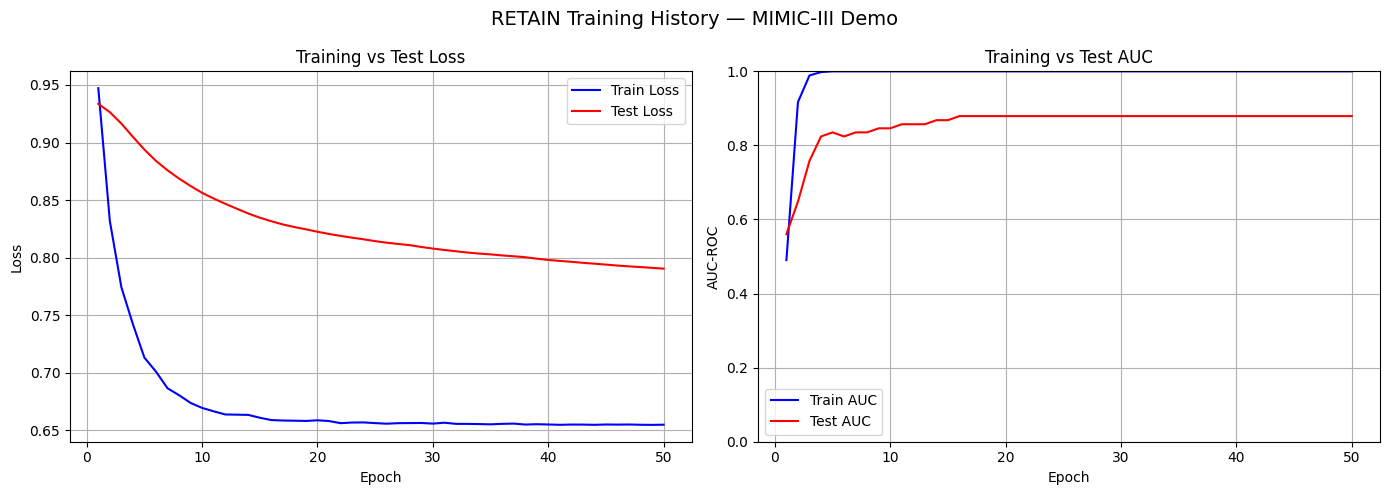

Plot saved to Drive ✓


In [24]:
import matplotlib.pyplot as plt

train_losses = [x[0] for x in train_history]
train_aucs   = [x[1] for x in train_history]
test_losses  = [x[0] for x in test_history]
test_aucs    = [x[1] for x in test_history]

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs_range, train_losses, label='Train Loss', color='blue')
ax1.plot(epochs_range, test_losses,  label='Test Loss',  color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Test Loss')
ax1.legend()
ax1.grid(True)

# AUC plot
ax2.plot(epochs_range, train_aucs, label='Train AUC', color='blue')
ax2.plot(epochs_range, test_aucs,  label='Test AUC',  color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.set_title('Training vs Test AUC')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True)

plt.suptitle('RETAIN Training History — MIMIC-III Demo', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_PATH + 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to Drive ✓")

In [25]:
def compute_contributions(model, visit_codes_list):
    max_codes = max(len(v) for v in visit_codes_list)
    padded    = []
    for visit in visit_codes_list:
        padded.append(visit + [0] * (max_codes - len(visit)))

    x       = torch.tensor([padded], dtype=torch.long)
    lengths = torch.tensor([len(visit_codes_list)], dtype=torch.long)

    with torch.no_grad():
        pred, alpha, beta = model(x, lengths)

    pred  = pred.item()
    alpha = alpha.squeeze(0).numpy()
    beta  = beta.squeeze(0).numpy()
    W     = model.output.weight.detach().numpy()

    contributions = []

    for j, visit_codes in enumerate(visit_codes_list):
        visit_contribs = {}
        alpha_j = alpha[j][0]
        beta_j  = beta[j]

        for code_idx in visit_codes:
            if code_idx == 0:
                continue
            emb_k    = model.embedding.weight[code_idx].detach().numpy()
            filtered = beta_j * emb_k
            coeff    = float(W @ filtered)
            omega    = alpha_j * coeff
            icd_code = idx_to_code.get(code_idx, str(code_idx))
            visit_contribs[icd_code] = round(float(omega), 4)

        contributions.append({
            'alpha':         round(float(alpha_j), 4),
            'contributions': visit_contribs
        })

    return pred, contributions

print("Contribution function defined ✓")

Contribution function defined ✓


In [26]:
def visualize_patient(subject_id):

    visit_code_indices = patient_sequences[subject_id]
    true_label         = labels[subject_id]

    pred, contributions = compute_contributions(model, visit_code_indices)

    print(f"{'='*60}")
    print(f"Patient {subject_id}")
    print(f"True Label:  {'Heart Failure' if true_label == 1 else 'No Heart Failure'}")
    print(f"Predicted:   {pred:.4f} ({'Heart Failure' if pred > 0.5 else 'No Heart Failure'}")
    print(f"{'='*60}")

    for v_idx, visit_data in enumerate(contributions):
        alpha_j  = visit_data['alpha']
        contribs = visit_data['contributions']

        print(f"\nVisit {v_idx+1} — Importance (α): {alpha_j:.4f}")
        print(f"  {'ICD Code':<12} {'Contribution':>14}")
        print(f"  {'-'*28}")

        sorted_codes = sorted(
            contribs.items(),
            key=lambda x: abs(x[1]),
            reverse=True
        )[:10]

        for code, omega in sorted_codes:
            bar  = '█' * int(abs(omega) * 30)
            sign = '+' if omega > 0 else '-'
            print(f"  {code:<12} {sign}{abs(omega):.4f}  {bar}")


hf_patients  = [pid for pid, lbl in labels.items() if lbl == 1]
nohf_patients = [pid for pid, lbl in labels.items() if lbl == 0]

print(f"Heart failure patients available: {len(hf_patients)}")
print(f"First 5: {hf_patients[:5]}")

Heart failure patients available: 35
First 5: [10006, 10027, 10029, 10032, 10038]


In [27]:
visualize_patient(10006)

Patient 10006
True Label:  Heart Failure
Predicted:   0.9976 (Heart Failure

Visit 1 — Importance (α): 1.0000
  ICD Code       Contribution
  ----------------------------
  4280         +1.8656  ███████████████████████████████████████████████████████
  25000        +1.0635  ███████████████████████████████
  5672         +0.8485  █████████████████████████
  03819        -0.8135  ████████████████████████
  4241         +0.7341  ██████████████████████
  28529        +0.6910  ████████████████████
  99662        -0.6816  ████████████████████
  E9342        +0.6487  ███████████████████
  42731        +0.5498  ████████████████
  2874         +0.5224  ███████████████


/tmp/ipykernel_1288/3680417334.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coeff    = float(W @ filtered)


In [28]:
visualize_patient(10027)

Patient 10027
True Label:  Heart Failure
Predicted:   0.9997 (Heart Failure

Visit 1 — Importance (α): 1.0000
  ICD Code       Contribution
  ----------------------------
  4280         +1.8248  ██████████████████████████████████████████████████████
  41401        +1.2002  ████████████████████████████████████
  25000        +1.0814  ████████████████████████████████
  4240         +0.8916  ██████████████████████████
  2948         +0.7975  ███████████████████████
  3970         +0.5643  ████████████████
  5859         +0.4526  █████████████
  4019         +0.4281  ████████████
  42731        +0.3947  ███████████
  5691         +0.1741  █████


/tmp/ipykernel_1288/3680417334.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coeff    = float(W @ filtered)


In [29]:
visualize_patient(nohf_patients[0])

Patient 10011
True Label:  No Heart Failure
Predicted:   0.0025 (No Heart Failure

Visit 1 — Importance (α): 1.0000
  ICD Code       Contribution
  ----------------------------
  30401        -1.2360  █████████████████████████████████████
  07030        -1.1524  ██████████████████████████████████
  07054        -1.1246  █████████████████████████████████
  2760         -1.0023  ██████████████████████████████
  570          -0.7427  ██████████████████████
  2875         -0.6079  ██████████████████


/tmp/ipykernel_1288/3680417334.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coeff    = float(W @ filtered)


/tmp/ipykernel_1288/3680417334.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  coeff    = float(W @ filtered)


NameError: name 'mpatches' is not defined

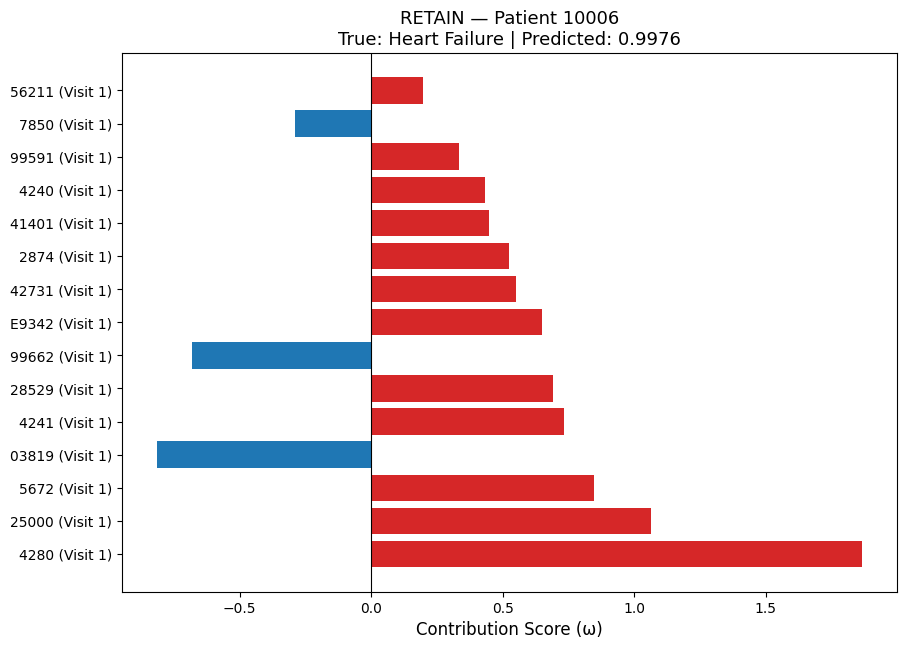

In [30]:
def plot_patient(subject_id):

    visit_code_indices  = patient_sequences[subject_id]
    true_label          = labels[subject_id]
    pred, contributions = compute_contributions(model, visit_code_indices)

    # Collect all codes across all visits
    all_codes  = []
    all_omegas = []
    all_visits = []

    for v_idx, visit_data in enumerate(contributions):
        for code, omega in visit_data['contributions'].items():
            all_codes.append(code)
            all_omegas.append(omega)
            all_visits.append(v_idx + 1)

    # Sort by contribution value
    sorted_indices = np.argsort(all_omegas)
    sorted_codes   = [all_codes[i]  for i in sorted_indices]
    sorted_omegas  = [all_omegas[i] for i in sorted_indices]
    sorted_visits  = [all_visits[i] for i in sorted_indices]

    # Take top 15 by absolute value
    abs_sorted = sorted(
        zip(all_codes, all_omegas, all_visits),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:15]

    codes_plot  = [x[0] for x in abs_sorted]
    omegas_plot = [x[1] for x in abs_sorted]
    visits_plot = [x[2] for x in abs_sorted]

    # Colors — positive=red, negative=blue
    colors = ['#d62728' if o > 0 else '#1f77b4' for o in omegas_plot]

    fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(range(len(codes_plot)), omegas_plot, color=colors)
    ax.set_yticks(range(len(codes_plot)))
    ax.set_yticklabels([f"{c} (Visit {v})"
                        for c, v in zip(codes_plot, visits_plot)],
                       fontsize=10)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribution Score (ω)', fontsize=12)
    ax.set_title(
        f'RETAIN — Patient {subject_id}\n'
        f'True: {"Heart Failure" if true_label==1 else "No HF"} | '
        f'Predicted: {pred:.4f}',
        fontsize=13
    )

    red_patch  = mpatches.Patch(color='#d62728', label='Pushes toward HF')
    blue_patch = mpatches.Patch(color='#1f77b4', label='Pushes away from HF')
    ax.legend(handles=[red_patch, blue_patch], fontsize=10)

    plt.tight_layout()
    plt.savefig(BASE_PATH + f'patient_{subject_id}_contributions.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved ✓")


# Plot both patients
plot_patient(10006)
plot_patient(10011)